In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
url = "/content/drive/MyDrive/Colab Notebooks/student_habits_performance.csv"

In [ ]:
df = pd.read_csv(url)

In [ ]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [ ]:
df['parental_education_level'] = df['parental_education_level'].fillna("No formal education")

In [ ]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


                     study_hours_per_day  exam_score
study_hours_per_day             1.000000    0.807023
exam_score                      0.807023    1.000000


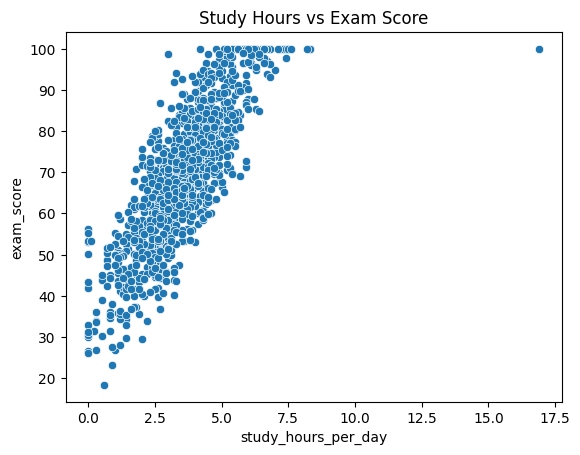

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation
print(df[['study_hours_per_day', 'exam_score']].corr())

# Scatter plot
sns.scatterplot(x='study_hours_per_day', y='exam_score', data=df)
plt.title("Study Hours vs Exam Score")
plt.show()

In [ ]:
df['entertainment_time'] = df['social_media_hours'] + df['netflix_hours']

                    entertainment_time  exam_score
entertainment_time            1.000000   -0.237631
exam_score                   -0.237631    1.000000


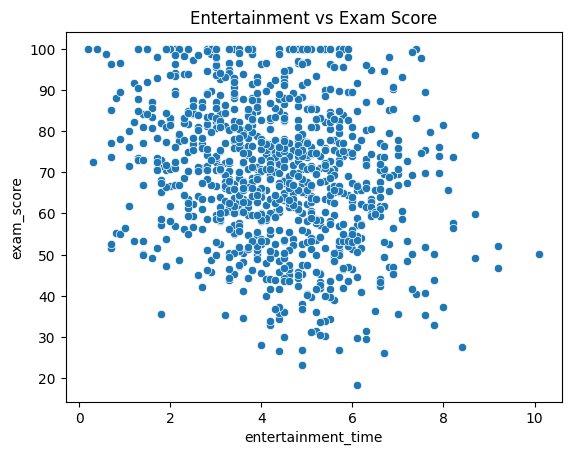

In [ ]:
# Correlation
print(df[['entertainment_time', 'exam_score']].corr())

# Scatter plot
sns.scatterplot(x='entertainment_time', y='exam_score', data=df)
plt.title("Entertainment vs Exam Score")
plt.show()

                      mental_health_rating  exam_score
mental_health_rating              1.000000    0.321523
exam_score                        0.321523    1.000000


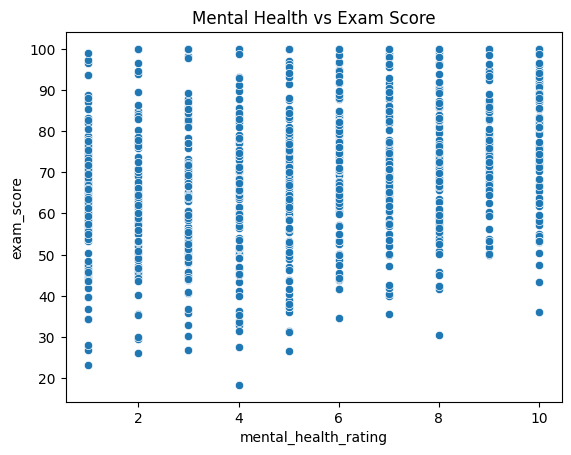

In [ ]:
# Correlation
print(df[['mental_health_rating', 'exam_score']].corr())

# Boxplot
sns.scatterplot(x='mental_health_rating', y='exam_score', data=df)
plt.title("Mental Health vs Exam Score")
plt.show()

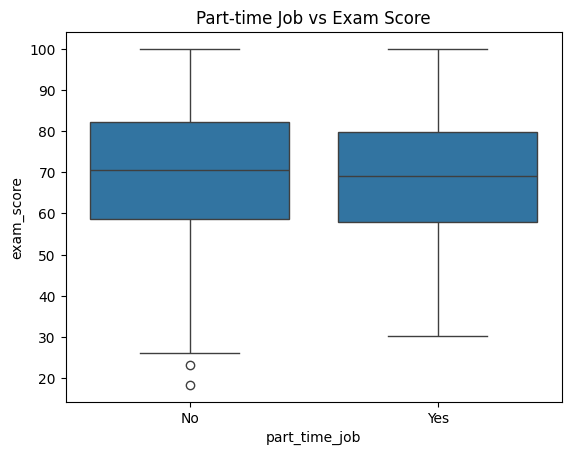

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='part_time_job', y='exam_score', data=df)
plt.title("Part-time Job vs Exam Score")
plt.show()

In [ ]:
df.groupby('part_time_job')['exam_score'].mean()

,exam_score
part_time_job,
No,69.836561
Yes,68.743256


In [ ]:
df['health_score'] = df['sleep_hours'] + df['exercise_frequency']

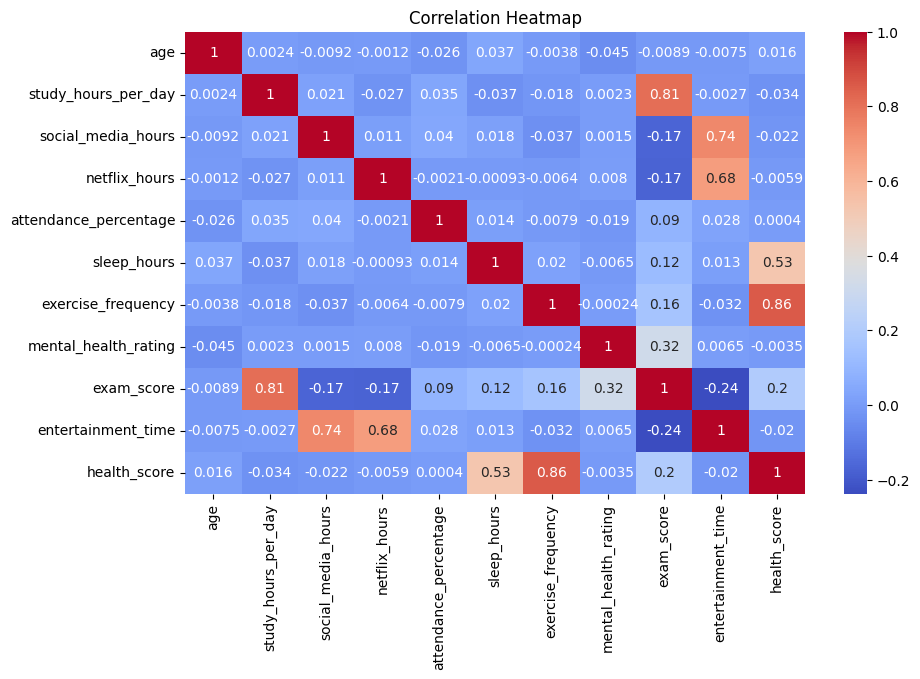

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
!pip install scikit-learn

In [ ]:
import sklearn

In [ ]:
df["part_time_job"] = df["part_time_job"].map({"Yes": 1, "No": 0})


In [ ]:
df = pd.get_dummies(df, columns=["gender"])

In [ ]:
df["extracurricular_participation"] = df["extracurricular_participation"].map({"Yes": 1, "No": 0})


In [ ]:
df = pd.get_dummies(df, columns=["diet_quality"])

In [ ]:
df = pd.get_dummies(df, columns=["internet_quality"])

In [ ]:
df["parental_education_level"] = df["parental_education_level"].astype(str).str.lower().str.strip()

In [ ]:
df["parental_education_level"] = df["parental_education_level"].map({
    "no formal education": 0,
    "high school": 1,
    "bachelor": 2,
    "master": 3
})

In [ ]:
print(df["parental_education_level"].unique())

[3 1 2 0]


In [ ]:
df["pass_fail"] = df["exam_score"].apply(lambda x: 1 if x >= 50 else 0)

In [ ]:
X = df.drop(["exam_score", "pass_fail", "student_id"], axis=1)

y_reg = df["exam_score"]   # regression
y_clf = df["pass_fail"]    # classification

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.3)
_, _, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=0.3)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()

lr.fit(X_train, y_reg_train)
dt.fit(X_train, y_reg_train)
rf.fit(X_train, y_reg_train)

RandomForestRegressor()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt_clf = DecisionTreeClassifier()
rf_clf = RandomForestClassifier()

dt_clf.fit(X_train, y_clf_train)
rf_clf.fit(X_train, y_clf_train)

RandomForestClassifier()

In [ ]:
# Regression
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

# Classification
dt_clf_pred = dt_clf.predict(X_test)
rf_clf_pred = rf_clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
dt_acc = accuracy_score(y_clf_test, dt_clf_pred)
rf_acc = accuracy_score(y_clf_test, rf_clf_pred)
print("Decision Tree Accuracy:",dt_acc )
print("Random Forest Accuracy:", rf_acc)

Decision Tree Accuracy: 0.7333333333333333
Random Forest Accuracy: 0.8366666666666667


In [ ]:
dt_acc = accuracy_score(y_clf_test, dt_clf_pred)
rf_acc = accuracy_score(y_clf_test, rf_clf_pred)
DT_Error_Rate = 1 - dt_acc
RF_Error_Rate =  1 - rf_acc
print("DT Error Rate:", DT_Error_Rate)
print("RF Error Rate:",RF_Error_Rate)

DT Error Rate: 0.2666666666666667
RF Error Rate: 0.16333333333333333


In [ ]:
from sklearn.metrics import r2_score

print("R2 Score RF:", r2_score(y_reg_test, rf_pred))

R2 Score RF: 0.8756136258498729


In [ ]:
df['predicted_score'] = rf.predict(X)
df.to_csv("final_dataset.csv", index=False)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# MAE
lr_mae = mean_absolute_error(y_reg_test, lr_pred)
dt_mae = mean_absolute_error(y_reg_test, dt_pred)
rf_mae = mean_absolute_error(y_reg_test, rf_pred)

# RMSE
lr_rmse = np.sqrt(mean_squared_error(y_reg_test, lr_pred))
dt_rmse = np.sqrt(mean_squared_error(y_reg_test, dt_pred))
rf_rmse = np.sqrt(mean_squared_error(y_reg_test, rf_pred))

# R2 Score
lr_r2 = r2_score(y_reg_test, lr_pred)
dt_r2 = r2_score(y_reg_test, dt_pred)
rf_r2 = r2_score(y_reg_test, rf_pred)

In [ ]:
model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2 Score": [lr_r2, dt_r2, rf_r2],
    "MAE": [lr_mae, dt_mae, rf_mae],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse]
})

In [ ]:
model_results.to_csv("model_results.csv", index=False)

In [ ]:
model_results_2 = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy_score": [dt_acc, rf_acc],
    "Error_rate": [DT_Error_Rate, RF_Error_Rate],

})

In [ ]:
model_results_2.to_csv("model_results_2.csv", index=False)